## Regression


### 1. Loading and Preprocessing:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [3]:
df = pd.DataFrame(housing.data,columns = housing.feature_names)
df['target'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.shape

(20640, 9)

In [7]:
for col in df.columns:
    print("Column:",col)
    print(df[col].value_counts())

Column: MedInc
MedInc
3.1250     49
15.0001    49
2.8750     46
2.6250     44
4.1250     44
           ..
4.0774      1
4.1767      1
6.1814      1
6.4319      1
2.0943      1
Name: count, Length: 12928, dtype: int64
Column: HouseAge
HouseAge
52.0    1273
36.0     862
35.0     824
16.0     771
17.0     698
34.0     689
26.0     619
33.0     615
18.0     570
25.0     566
32.0     565
37.0     537
15.0     512
19.0     502
27.0     488
24.0     478
30.0     476
28.0     471
20.0     465
29.0     461
31.0     458
23.0     448
21.0     446
14.0     412
22.0     399
38.0     394
39.0     369
42.0     368
44.0     356
43.0     353
40.0     304
13.0     302
41.0     296
45.0     294
10.0     264
11.0     254
46.0     245
5.0      244
12.0     238
8.0      206
9.0      205
47.0     198
4.0      191
48.0     177
7.0      175
6.0      160
50.0     136
49.0     134
3.0       62
2.0       58
51.0      48
1.0        4
Name: count, dtype: int64
Column: AveRooms
AveRooms
5.000000    27
4.500000    22

<Axes: >

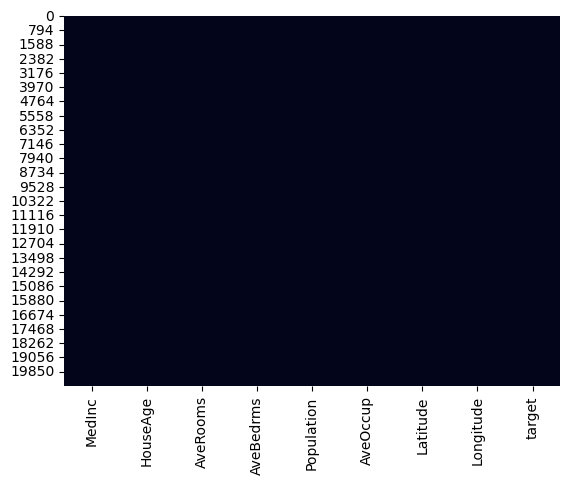

In [8]:
# To detect null values

sns.heatmap(df.isnull(),cbar=False)

In [9]:
# Deleting duplicates

df.drop_duplicates(inplace=True)

In [10]:
cols = df.select_dtypes(include=np.number)
cols.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')

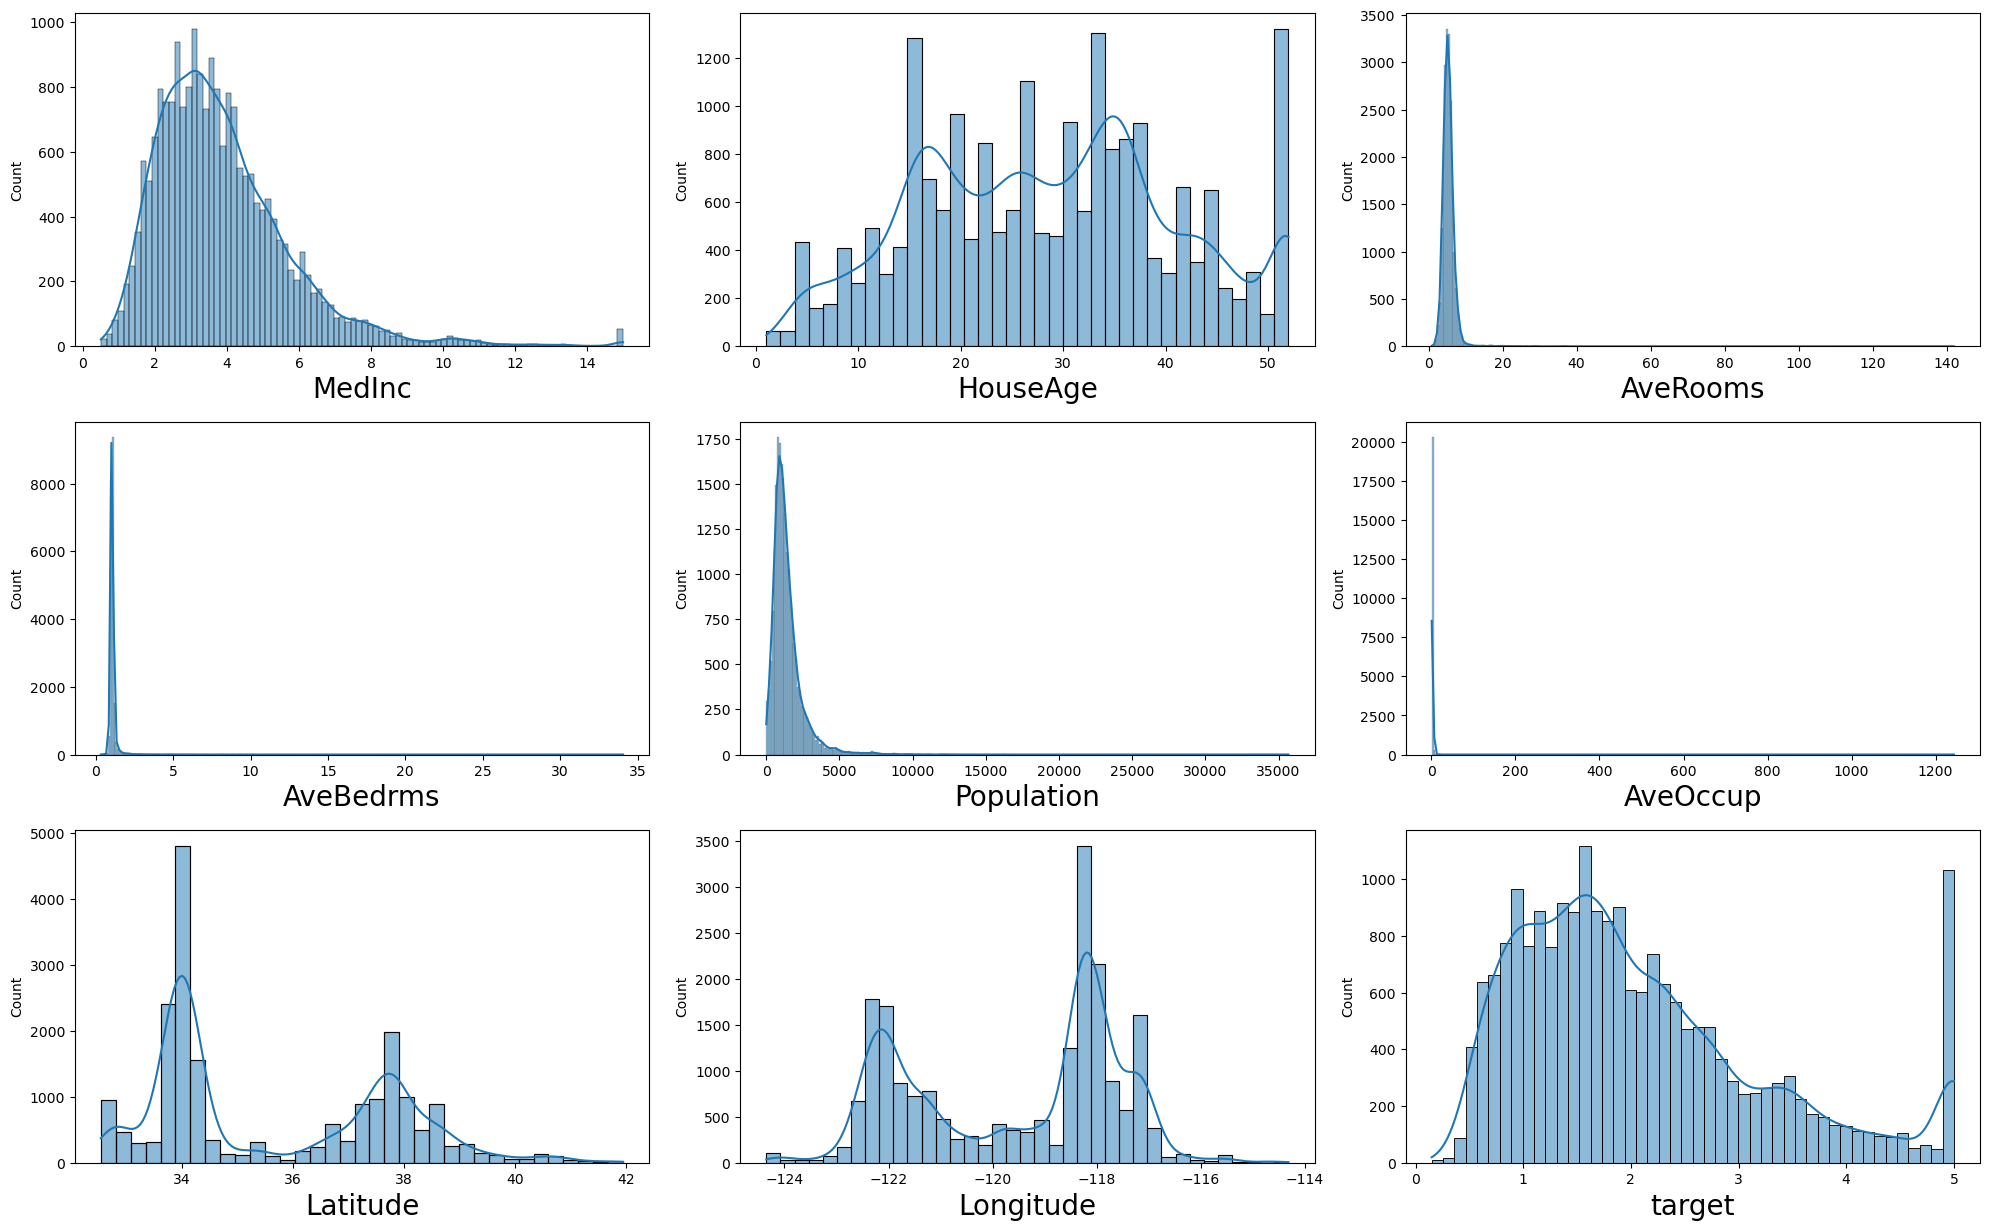

In [11]:
plt.figure(figsize=(20,20))
plotnumber =1
for column in cols:
    if plotnumber<=15:
        ax=plt.subplot(5,3,plotnumber)
        sns.histplot(cols[column],kde=True)
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.tight_layout()

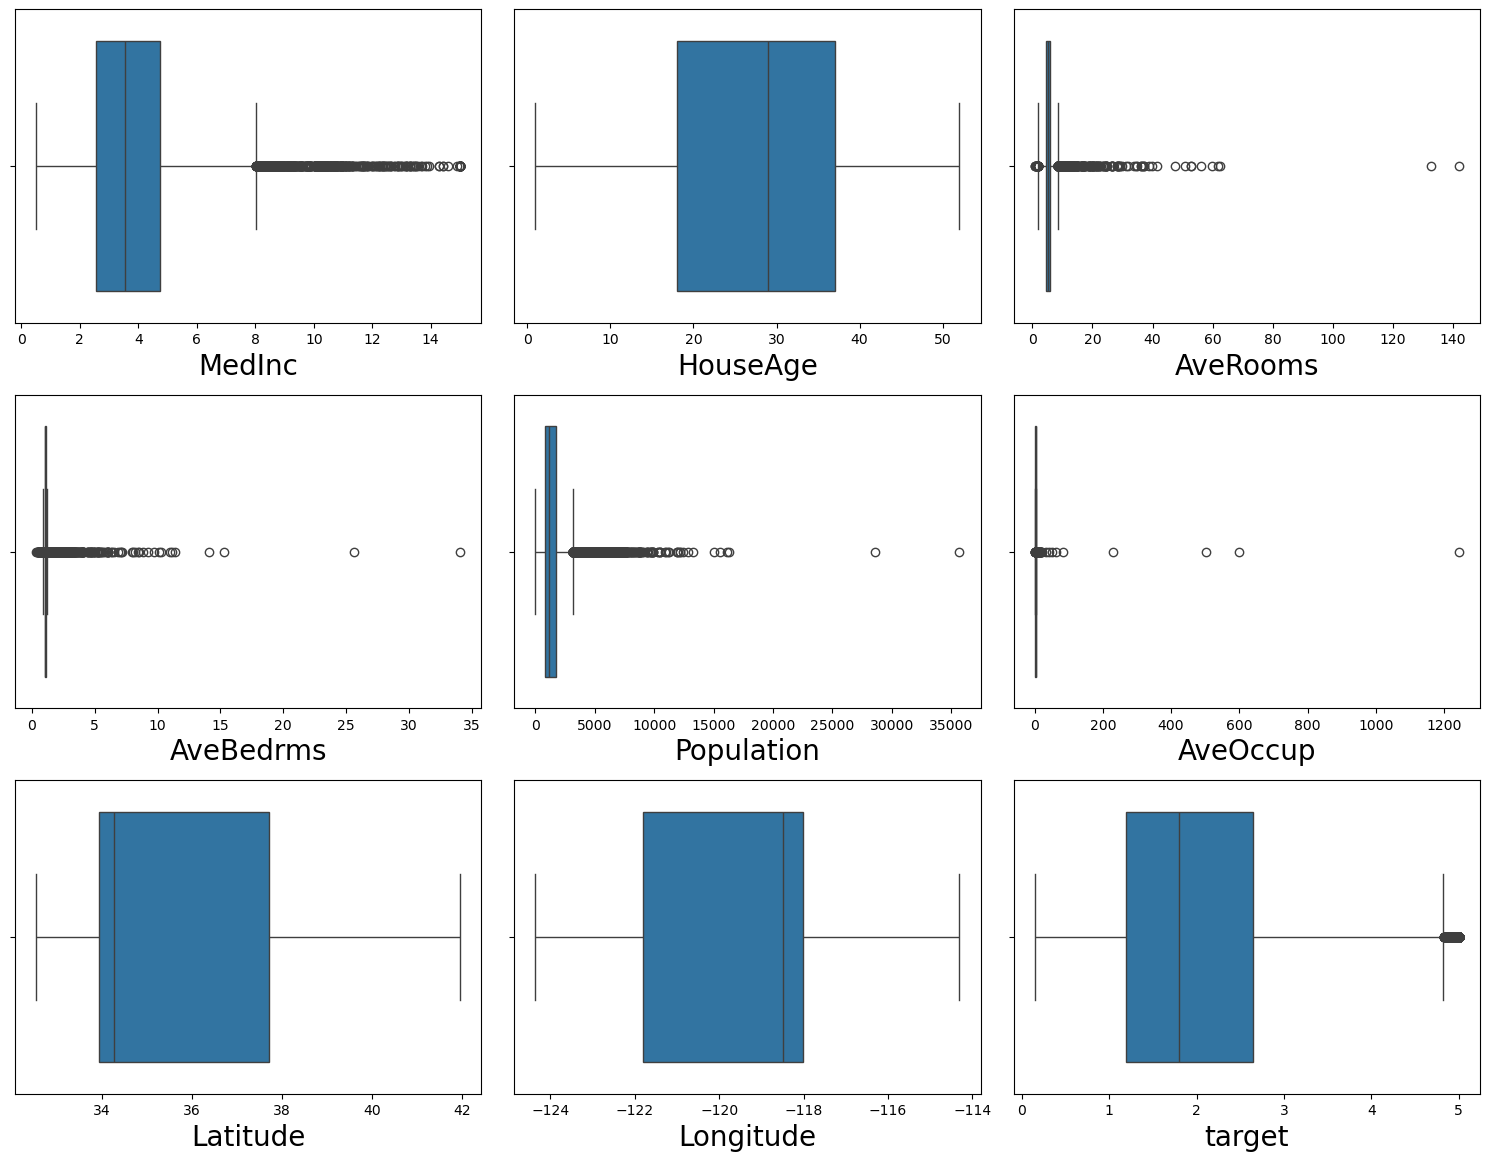

In [12]:
# Handling Outliers

plt.figure(figsize=(15,15))
plotnumber =1
for column in cols:
    if plotnumber<=15:
        ax=plt.subplot(4,3,plotnumber)
        sns.boxplot(x=column,data=df)
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.tight_layout()

In [13]:
def remove_outliers_iqr(data, column):
  q1,q2,q3 = np.percentile(data[column],[25,50,75])
  print("q1,q2,q3 is :",q1,q2,q3)
  IQR = q3-q1
  print("IQR is :" ,IQR)
  lower_limit = q1-(1.5*IQR)
  upper_limit = q3+(1.5*IQR)
  data[column]=np.where(data[column]>upper_limit,upper_limit,data[column])
  data[column]=np.where(data[column]<lower_limit,lower_limit,data[column]) 

In [14]:
for column in cols:
    remove_outliers_iqr(df,column)

q1,q2,q3 is : 2.5633999999999997 3.5347999999999997 4.74325
IQR is : 2.17985
q1,q2,q3 is : 18.0 29.0 37.0
IQR is : 19.0
q1,q2,q3 is : 4.440716235896959 5.229128787878788 6.052380952380952
IQR is : 1.6116647164839932
q1,q2,q3 is : 1.006079046038478 1.048780487804878 1.099526066350711
IQR is : 0.09344702031223284
q1,q2,q3 is : 787.0 1166.0 1725.0
IQR is : 938.0
q1,q2,q3 is : 2.4297411475535755 2.818115654360196 3.2822609242736216
IQR is : 0.8525197767200461
q1,q2,q3 is : 33.93 34.26 37.71
IQR is : 3.780000000000001
q1,q2,q3 is : -121.8 -118.49 -118.01
IQR is : 3.789999999999992
q1,q2,q3 is : 1.196 1.797 2.6472499999999997
IQR is : 1.4512499999999997


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [16]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')

<Axes: >

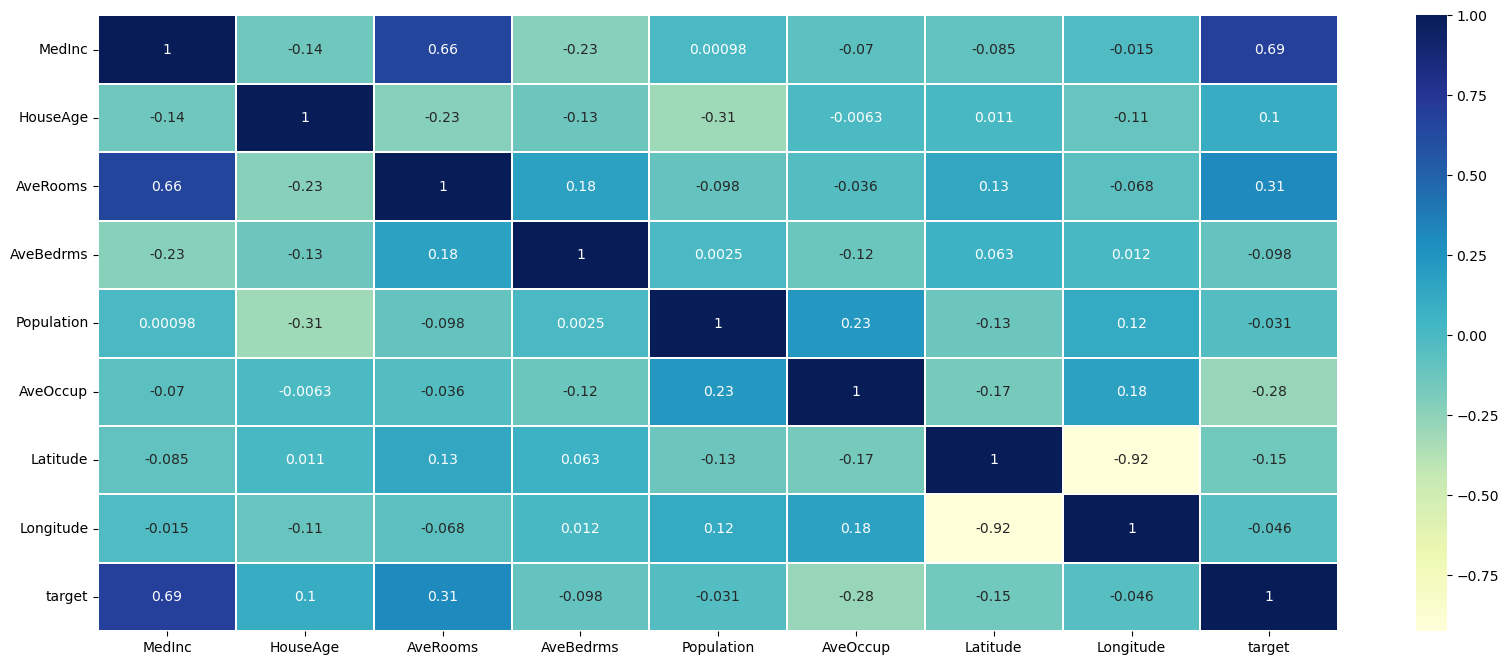

In [17]:
# For selecting features

cor_matrix= df.corr()
plt.subplots(figsize=(20,8))
sns.heatmap(cor_matrix,annot=True,cmap='YlGnBu',linewidth=0.2)

In [18]:
x = df.drop('target',axis=1)
y = df['target']

In [19]:
# Standard Scaling

from sklearn.preprocessing import StandardScaler
standadisation = StandardScaler()
x = standadisation.fit_transform(x)

# For convert to DF
x = pd.DataFrame(x)
x.describe()

,0,1,2,3,4,5,6,7
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,-8.262125e-17,4.406467e-17,2.313395e-16,-6.857564e-16,1.239319e-16,-1.321940e-16,2.247298e-15,-8.603626e-15
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-1.991479e+00,-2.196180e+00,-2.633335e+00,-2.387314e+00,-1.742525e+00,-2.530199e+00,-1.447568e+00,-2.385992e+00
25%,-7.466196e-01,-8.453931e-01,-6.933564e-01,-6.448912e-01,-7.184008e-01,-6.799133e-01,-7.967887e-01,-1.113209e+00
50%,-1.605978e-01,2.864572e-02,-6.067586e-02,-1.140809e-01,-2.233204e-01,-1.179684e-01,-6.422871e-01,5.389137e-01
75%,5.684305e-01,6.643103e-01,5.999626e-01,5.167240e-01,5.068904e-01,5.536104e-01,9.729566e-01,7.784964e-01
max,2.541006e+00,1.856182e+00,2.539941e+00,2.259147e+00,2.344827e+00,2.403896e+00,2.958068e+00,2.625280e+00


#### Processing Steps Performed:
##### Loading the data set,
##### Data Exploration (Including exploration of the data,value counts for unique features and statistical analysis)
##### Data Cleaning(Dealing with null values,droping duplicates,handling outliers)
##### Data Analysis(Visual representaion of each columns in data for skewness)
##### Data Encoding (encoding steps for numerical data)
##### Feature Scaling(Scaling by standard scaling)


##### All these steps are necessary for this data set. Because these preprocessing steps make the data more accurate to perform for machine learning models.

### 2. Regression Algorithm Implementation:

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.33)

In [22]:
# Trainig the model(Linear Regression)

from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
# Prediction

y_pred0 = lr_model.predict(x_test)
y_pred0

array([0.25741411, 1.97357726, 3.42587421, ..., 1.04549724, 1.46711107,
       2.34078031], shape=(6812,))

In [24]:
# Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor
dtr_model = DecisionTreeRegressor()
dtr_model.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [25]:
# Prediction

y_pred1 = dtr_model.predict(x_test)
y_pred1


array([0.465   , 0.737   , 4.824125, ..., 1.33    , 1.628   , 2.875   ],
      shape=(6812,))

In [26]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
rfr_model = RandomForestRegressor()
rfr_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred2 = rfr_model.predict(x_test)
y_pred2

array([0.54275  , 0.74549  , 4.776465 , ..., 1.18486  , 1.38038  ,
       3.3048975], shape=(6812,))

In [28]:
# Gradient Boosting Regressor 

from sklearn.ensemble import GradientBoostingRegressor
gbr_model = GradientBoostingRegressor()
gbr_model.fit(x_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [29]:
y_pred3 = gbr_model.predict(x_test)
y_pred3

array([0.54944719, 0.98098723, 4.10964364, ..., 1.2669471 , 1.3362942 ,
       2.70509872], shape=(6812,))

In [30]:
# Support Vector Regressor (SVR) 

from sklearn.svm import SVR
svr_model = SVR()
svr_model.fit(x_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [31]:
y_pred4 = svr_model.predict(x_test)
y_pred4

array([0.48520531, 1.48406256, 4.61343257, ..., 1.1310361 , 1.27848421,
       2.35946123], shape=(6812,))

#### Linear Regression:
##### Predict values using a linear relationship between input features and target variable.

#### Decision Tree Regressor:
##### Splits data into branches based on features conditions to make predictions.

#### Random Forest Regressor:
##### Uses multiple decision trees and averages their predictions for better accuracy.

#### Gradient Boosting Regressor:
##### Builds trees sequentially where each tree corrects previos errors.

#### Support Vector regressor(SVR)
##### Finds the best boundary that minimizes prediction error using support vectores.

##### All this models might be suitable for this dataset.



### 3. Model Evaluation and Comparison:

In [32]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [35]:
mse0 = mean_squared_error(y_test,y_pred0)
mae0 = mean_absolute_error(y_test,y_pred0)
r0 = r2_score(y_test,y_pred0)

In [36]:
print(mse0)
print(mae0)
print(r0)

0.4317117374925067
0.49126098010380725
0.663683267952792


In [37]:
mse1 = mean_squared_error(y_test,y_pred1)
mae1 = mean_absolute_error(y_test,y_pred1)
r1 = r2_score(y_test,y_pred1)

In [38]:
print(mse1)
print(mae1)
print(r1)

0.5299121479576921
0.470827588079859
0.5871821254886753


In [39]:
mse2 = mean_squared_error(y_test,y_pred2)
mae2 = mean_absolute_error(y_test,y_pred2)
r2 = r2_score(y_test,y_pred2)

In [40]:
print(mse2)
print(mae2)
print(r2)

0.24952495504079278
0.33204436465795667
0.8056123793831236


In [41]:
mse3 = mean_squared_error(y_test,y_pred3)
mae3 = mean_absolute_error(y_test,y_pred3)
r3 = r2_score(y_test,y_pred3)

In [42]:
print(mse3)
print(mae3)
print(r3)

0.27688152484409
0.365213249997648
0.7843007694424141


In [43]:
mse4 = mean_squared_error(y_test,y_pred4)
mae4 = mean_absolute_error(y_test,y_pred4)
r4 = r2_score(y_test,y_pred4)

In [44]:
print(mse4)
print(mae4)
print(r4)

0.2989122846799627
0.3697922835520768
0.767138129400351


#### Randon Forest Regressor is the best performing algorithm.Because it has lower mean squared error and mean absolute error also less in r-square score when compaired to others.
#### And the worst performing algorithm is Decision Tree regressor.Because it has highest values of mean squared error,mean absolute error and lowest value of r-square score when compaired to other algorithms for the given data.The worst perfomance done due to overfitting of the data.